# Day 6 - Basic Satellite Link Budget 

In this notebook, i will build a simple satellite communication link-budget calculator

The goal is to estimate received power, noise power, and link margin for a sateöllite-to-ground communication link.

## Link Budget Theory

A link budget estimates whether a communication link has enough received signal power compared with noise

The basic received power equation in dB form is: 

\[
P_r = P_t + G_t - L_{FS} - L_{other}
\]

where: 

- \(P_r\) is received power in dBW
- \(P_t\) is transmit power in dBW
- \(G_t\) is transmit antenna gain in dBi
- \(G_r\) is receive antenna gain in dBi
- \(L_{FS}\) is free-space path loss in dB
- \(L_{other}\) represents additional losses in dB

Noise power is:

\[
N = kTB
\]

where:

- \(k\) is Boltzmann's constant
- \(T\) is system noise temperature in kelvin
- \(B\) is receiver bandwidth in Hz


The signal-to-noise ratio is:

\[
SNR_{dB} = P_{r,dBW} - N_{dBW}
\]

The link margin is:

\[
Margin = SNR_{dB} - SNR_{required,dB}
\]

if margin is positive, the simplified link is considered usable.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path # help us saving plot files cleanly

In [6]:
SPEED_OF_LIGHT_M_PER_S = 299_792_458
BOLTZMANN_CONSTANT_J_PER_K = 1.380649e-23
# we need the bolzmann constant to calculate thermal noise power

In [7]:
# Helper Functions
def watts_to_dbw(power_watts):
    """
    Conver power from watts to dBW

    dBW means decibels relative to 1 watt

    Example: 
    1W = 0 dBW
    10W = 10 dBW
    """
    power_dbw = 10 * np.log(power_watts)
    return power_dbw

# this function converts watts into dBW, this function is why dB units are convenient: multiplication and division become addition and subtraction

def dbw_to_watts(power_dbw):
    """
    Convert power from dBW to watts
    """
    power_watts = 10 ** (power_dbw / 10)
    return power_watts

# this is inverse conversion, the equation: Pw = 10^(P_dBW/10)

def calculate_fspl_db(range_m, frequency_hz):
    """
    Calculate free-space path loss in dB
    """
    fspl_db = 20 * np.log10(4 * np.pi * range_m * frequency_hz) / SPEED_OF_LIGHT_M_PER_S
    return fspl_db

# free space path loss formula is used for lin budget calculation again which needs path loss.

def calculate_received_power_dbw(transmit_power_dbw, transmit_antenna_gain_dbi, receive_antenna_gain_dbi, fspl_db, other_losses_db,):
    """
    Calculate received power in dBW using a simple link-budget equation 
    """
    received_power_dbw = transmit_power_dbw + transmit_antenna_gain_dbi + receive_antenna_gain_dbi - fspl_db - other_losses_db

    return received_power_dbw

# received power = transmit power + gains - losses
# a negative dBW value is normal. Satellite received signals are usually very weak

def calculate_noise_power_dbw(system_noise_temperature_k, bandwidth_hz):
    """
    Calculate thermal noise power in dBW
    """
    noise_power_watts = (BOLTZMANN_CONSTANT_J_PER_K * system_noise_temperature_k * bandwidth_hz)

    noise_power_dbw = watts_to_dbw(noise_power_watts)

    return noise_power_dbw

    # this calculates thermal noise power 
    # Noise increases when: 
    # system noise temperature increases 
    # bandwith increases
    # wider receiver bandwidth collects more noise 
    # important in satcom

def calculate_snr_db(received_power_dbw, noise_power_dbw):

    """
    Calculate signal-to-noise ratio in dB
    """

    snr_db = received_power_dbw - noise_power_dbw
    return snr_db

# example received_power = -101 dBW
# noise power = -142 dBW
# SNR = -101 - (-142) = 41 dB
# because both values are in dBW, substracting them gives SNR in dB

def calculate_link_margin_db(snr_db, required_snr_db):

    """
    Calculate link margin in dB
    """
    link_margin_db = snr_db - required_snr_db
    return link_margin_db

# this tells us how much extra SNR we have
#  Negative margin means the link probably does not closure under the assumptions


In [12]:
# define link parameters 

frequency_hz = 2. # Example: S band 2.2 GHz

transmit_power_watts = 10
transmit_power_dbw = watts_to_dbw(transmit_power_watts)

transmit_antenna_gain_dbi = 20
receive_antenna_gain_dbi = 30
other_losses_db = 2
# cable losses, implementation losses, polarization losses or pointing imperfections

system_noise_temperature_k = 500 # simplified receiver system noise temperature
bandwidth_hz = 1e6 # bandwidth 1 MHz

required_snr_db = 10
# this means we assume needs at least 10 dB SNR
# later, whe nwe study modulation and BER, we will conenct this to required Eb / N0

In [17]:
# calculate link budget at one range 

range_km = 1000
range_m  = range_km * 1000

fspl_db = calculate_fspl_db(range_m, frequency_hz)

received_power_dbw = calculate_received_power_dbw(
    transmit_power_dbw,
    transmit_antenna_gain_dbi,
    receive_antenna_gain_dbi,
    fspl_db,
    other_losses_db,
)

noise_power_dbw = calculate_noise_power_dbw(system_noise_temperature_k,bandwidth_hz)

snr_db = calculate_snr_db(received_power_dbw, noise_power_dbw)

link_margin_db = calculate_link_margin_db(snr_db, required_snr_db,)

print("Basic Satellite Link Budget")
print("----------------------------")
print(f"Frequency: {frequency_hz / 1e9:.2f} GHz")
print(f"Range: {range_km:.0f} km")
print()
print(f"Transmit power: {transmit_power_watts:.1f} W")
print(f"Transmit power: {transmit_power_dbw:.2f} dBW")
print(f"Transmit antenna gain: {transmit_antenna_gain_dbi:.2f} dBi")
print(f"Receive antenna gain: {receive_antenna_gain_dbi:.2f} dBi")
print(f"Other losses: {other_losses_db:.2f} dB")
print()
print(f"Free-space path loss: {fspl_db:.2f} dB")
print(f"Received power: {received_power_dbw:.2f} dBW")
print(f"Noise power: {noise_power_dbw:.2f} dBW")
print(f"SNR: {snr_db:.2f} dB")
print(f"Required SNR: {required_snr_db:.2f} dB")
print(f"Link margin: {link_margin_db:.2f} dB")

Basic Satellite Link Budget
----------------------------
Frequency: 0.00 GHz
Range: 1000 km

Transmit power: 10.0 W
Transmit power: 23.03 dBW
Transmit antenna gain: 20.00 dBi
Receive antenna gain: 30.00 dBi
Other losses: 2.00 dB

Free-space path loss: 0.00 dB
Received power: 71.03 dBW
Noise power: -326.07 dBW
SNR: 397.09 dB
Required SNR: 10.00 dB
Link margin: 387.09 dB


In [18]:
ranges_km = np.linspace(500, 40_000, 500)
ranges_m = ranges_km * 1000

fspl_db_array = calculate_fspl_db(ranges_m, frequency_hz)

received_power_dbw_array = calculate_received_power_dbw(
    transmit_power_dbw,
    transmit_antenna_gain_dbi,
    receive_antenna_gain_dbi,
    fspl_db_array,
    other_losses_db,
)

noise_power_dbw = calculate_noise_power_dbw(
    system_noise_temperature_k,
    bandwidth_hz,
)

snr_db_array = calculate_snr_db(
    received_power_dbw_array,
    noise_power_dbw,
)

link_margin_db_array = calculate_link_margin_db(
    snr_db_array,
    required_snr_db,
)

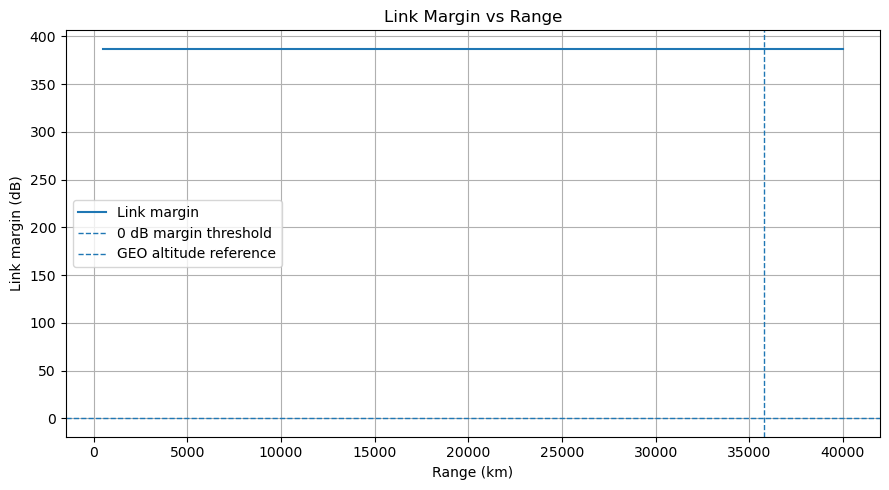

Saved plot to: 00_python_satcom_warmup\day06_link_margin_vs_range.png


In [19]:
plt.figure(figsize=(9, 5))

plt.plot(
    ranges_km,
    link_margin_db_array,
    label="Link margin"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
    label="0 dB margin threshold"
)

plt.axvline(
    35_786,
    linestyle="--",
    linewidth=1,
    label="GEO altitude reference"
)

plt.title("Link Margin vs Range")
plt.xlabel("Range (km)")
plt.ylabel("Link margin (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()

output_path = Path("00_python_satcom_warmup/day06_link_margin_vs_range.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved plot to: {output_path}")

## Engineering Interpretation

This notebook combines several SatCom quantities into a basic link budget.

The received power decreases as range increases because free-space path loss increases with range.

The noise power depends on receiver bandwidth and system noise temperature. A larger bandwidth or higher noise temperature increases noise power.

The SNR compares received signal power to noise power.

The link margin compares actual SNR to required SNR.

If link margin is positive, the simplified link is usable. If link margin is negative, the link does not close under these assumptions.

This notebook is simplified because it does not yet include atmospheric loss, rain fading, polarization loss, implementation loss models, antenna pointing loss, modulation, coding, or \(E_b/N_0\). These will be added later.